# Critical evaluation

**What:** Recomputes every sensitivity, ablation and comparability check on the ranking
algorithm's output, directly from stored result records and data files.

**Why:** So each number is produced by running code against evidence, not carried over from a
write-up. Run this notebook top to bottom once; every section ends in an `assert`.

In [ ]:
import glob
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = os.path.abspath("")
while REPO != os.path.dirname(REPO) and not os.path.isdir(os.path.join(REPO, "Dissertation")):
    REPO = os.path.dirname(REPO)

D18B = os.path.join(REPO, "Dissertation", "01_source_material", "project_evidence",
                     "evaluation", "research_revision", "results", "d18b")
VALIDATION = os.path.join(REPO, "validation")

print("repository root :", REPO)
print("evidence store  :", os.path.relpath(D18B, REPO))
assert os.path.isdir(D18B), "frozen D18B evidence store not found -- run this from az-team25"


repository root : E:\uob\final\az-team25
evidence store  : Dissertation\01_source_material\project_evidence\evaluation\research_revision\results\d18b


## 1. Load the stored result records

**What:** Loads the 301 stored comparison records (one per query, per rule variant) into a table.

**Why:** Every later check reads from this table, so it has to be loaded and counted first.

In [2]:
METRICS = ["rbo_at_10_p_0_9", "top10_jaccard", "top10_symmetric_difference",
           "kendall_tau_common_eligible", "partition_change_count"]
DENOMS = ["evaluated", "eligible", "low_confidence", "insufficient", "disqualified", "displayed"]
PARTITIONS = ["eligible", "low_confidence", "insufficient", "disqualified"]


def load_records(root=D18B):
    '''Read every stored Q07-*.json record into one row per record.'''
    rows = []
    for path in sorted(glob.glob(os.path.join(root, "*", "*", "Q07-*.json"))):
        rec = json.load(open(path, encoding="utf-8"))
        row = {"family": rec["family"], "variant": rec["variant_id"],
               "query": rec["canonical_query_id"], "status": rec["terminal_status"],
               "seed": rec.get("seed"), "raw_output": rec.get("raw_output")}
        for m in METRICS:
            row[m] = rec.get("metrics", {}).get(m)
        for dn in DENOMS:
            row[dn] = rec.get("denominators", {}).get(dn)
        rows.append(row)
    return pd.DataFrame(rows)


records = load_records()
passed = records[records.status == "passed"].copy()
blocked = records[records.status == "blocked"].copy()

print("total records   :", len(records))
print("passed          :", len(passed))
print("blocked         :", len(blocked))
print("distinct variants (passed + blocked):", records.variant.nunique())
print("distinct variants with a seven-query aggregate (passed only):", passed.variant.nunique())
assert len(records) == 301
assert len(passed) == 294
assert len(blocked) == 7
assert passed.variant.nunique() == 42
print("\nstructural counts reproduce: 301 records, 294 passed, 7 blocked, "
      "42 variants with a full seven-query aggregate (the 43rd variant, no_exact_zero_veto, "
      "is blocked -- see section 4)")


total records   : 301
passed          : 294
blocked         : 7


distinct variants (passed + blocked): 43
distinct variants with a seven-query aggregate (passed only): 42

structural counts reproduce: 301 records, 294 passed, 7 blocked, 42 variants with a full seven-query aggregate (the 43rd variant, no_exact_zero_veto, is blocked -- see section 4)


## 2. Independent metric recomputation

**What:** Recomputes RBO@10, Jaccard, symmetric difference, Kendall's tau, and partition-change
count directly from each record's ranked candidate lists.

**Why:** Checks that the stored metrics were computed correctly, instead of trusting the numbers
already saved in each file.

In [3]:
def rbo(a, b, p=0.9):
    '''Rank-biased overlap at the deepest of the two lists (max 10 here).'''
    n = min(10, max(len(a), len(b)))
    if not n:
        return None
    seen_a, seen_b, total = set(), set(), 0.0
    for d in range(1, n + 1):
        if d <= len(a):
            seen_a.add(a[d - 1])
        if d <= len(b):
            seen_b.add(b[d - 1])
        total += (len(seen_a & seen_b) / d) * p ** (d - 1)
    return (1 - p) * total + len(seen_a & seen_b) / n * p ** n


def kendall_tau_common(a, b, common):
    '''Kendall's tau restricted to identifiers both lists judge eligible.'''
    common = sorted(common)
    if len(common) < 2:
        return None
    pos_a = {x: i for i, x in enumerate(a) if x in common}
    pos_b = {x: i for i, x in enumerate(b) if x in common}
    concordant_minus_discordant = 0
    for i, x in enumerate(common):
        for y in common[i + 1:]:
            concordant_minus_discordant += (
                1 if (pos_a[x] - pos_a[y]) * (pos_b[x] - pos_b[y]) > 0 else -1
            )
    n_pairs = len(common) * (len(common) - 1) // 2
    return concordant_minus_discordant / n_pairs


def recompute_metrics(base_raw, other_raw):
    '''Recompute all five metrics for one (native, variant) pair from their raw partitions.'''
    common = set(base_raw["eligible"]) & set(other_raw["eligible"])
    a = [x for x in base_raw["eligible"] if x in common]
    b = [x for x in other_raw["eligible"] if x in common]
    top_a, top_b = set(a[:10]), set(b[:10])
    label_a = {x: part for part, ids in base_raw.items() for x in ids}
    label_b = {x: part for part, ids in other_raw.items() for x in ids}
    changed = sum(label_a.get(x) != label_b.get(x) for x in set(label_a) | set(label_b))
    return {
        "rbo_at_10_p_0_9": rbo(a[:10], b[:10]),
        "top10_jaccard": len(top_a & top_b) / len(top_a | top_b) if (top_a | top_b) else None,
        "top10_symmetric_difference": len(top_a ^ top_b),
        "kendall_tau_common_eligible": kendall_tau_common(a, b, common),
        "partition_change_count": changed,
    }


def close(x, y, tol=1e-9):
    if x is None or y is None:
        return x == y
    return abs(x - y) <= tol


native_by_query = {r.query: r.raw_output for r in passed[passed.variant == "full_native"].itertuples()}

mismatches = []
for r in passed.itertuples():
    recomputed = recompute_metrics(native_by_query[r.query], r.raw_output)
    for m in METRICS:
        stored = getattr(r, m)
        if not close(recomputed[m], stored):
            mismatches.append((r.family, r.variant, r.query, m, stored, recomputed[m]))

print("passed records checked :", len(passed))
print("metric mismatches      :", len(mismatches))
assert not mismatches, mismatches
print("\nevery stored metric on every passed record reproduces from the raw candidate lists")


passed records checked : 294
metric mismatches      : 0

every stored metric on every passed record reproduces from the raw candidate lists


## 3. Baselines and ablations

**What:** Computes the median and spread of each metric, over the seven queries, for the full
rule, three simplified baselines, and six single-layer removals.

**Why:** Shows how much the full rule's ordering depends on having all six evidence layers,
compared with simpler alternatives.

In [4]:
def summarise(frame):
    '''Median and IQR per (family, variant), over the seven canonical queries.'''
    rows = []
    for (fam, var), g in frame.groupby(["family", "variant"], sort=False):
        row = {"family": fam, "variant": var, "n": len(g)}
        for m in METRICS:
            v = g[m].astype(float).to_numpy()
            row[m] = float(np.median(v))
            row[m + "_iqr"] = float(np.percentile(v, 75) - np.percentile(v, 25))
        rows.append(row)
    return pd.DataFrame(rows).set_index("variant")


summary = summarise(passed)

# Values being checked against, variant by variant, in the order
# (RBO@10, Jaccard, symmetric difference, Kendall's tau, partition change).
CLAIMED_MEDIANS = {
    "full_native":                  (1.000, 1.000,  0, 1.000,   0),
    "equal_six_layer":              (0.822, 0.538,  6, 0.806,   0),
    "inclusion_exclusion_model_id": (0.000, 0.000, 20, 0.032, 502),
    "rna_only":                     (0.044, 0.053, 18, 0.560, 758),
    "leave_out_copy_number":        (0.389, 0.176, 14, 0.873, 117),
    "leave_out_dependency":         (0.251, 0.111, 16, 0.661,  13),
    "leave_out_fusion":             (0.212, 0.250, 12, 0.937,   0),
    "leave_out_mutation":           (0.925, 0.818,  2, 0.816, 310),
    "leave_out_protein":            (0.704, 0.818,  2, 0.948,   2),
    "leave_out_rna":                (0.858, 0.667,  4, 0.579,  63),
    "no_correlation_discount":      (1.000, 1.000,  0, 1.000,   0),
}

check_rows = []
for variant, claimed in CLAIMED_MEDIANS.items():
    got = tuple(round(summary.loc[variant, m], 3) for m in METRICS)
    ok = all(abs(a - b) <= 6e-4 for a, b in zip(got, claimed))
    check_rows.append({"claim": variant, "stated": claimed, "recomputed": got,
                        "verdict": "pass" if ok else "FAIL"})

baseline_ablation_check = pd.DataFrame(check_rows)
print(baseline_ablation_check.to_string(index=False))
assert (baseline_ablation_check.verdict == "pass").all()
print("\nall 11 baseline/ablation medians reproduce")


                       claim                         stated                         recomputed verdict
                 full_native          (1.0, 1.0, 0, 1.0, 0)          (1.0, 1.0, 0.0, 1.0, 0.0)    pass
             equal_six_layer    (0.822, 0.538, 6, 0.806, 0)    (0.822, 0.538, 6.0, 0.806, 0.0)    pass
inclusion_exclusion_model_id     (0.0, 0.0, 20, 0.032, 502)     (0.0, 0.0, 20.0, 0.032, 502.0)    pass
                    rna_only  (0.044, 0.053, 18, 0.56, 758)  (0.044, 0.053, 18.0, 0.56, 758.0)    pass
       leave_out_copy_number (0.389, 0.176, 14, 0.873, 117) (0.389, 0.176, 14.0, 0.873, 117.0)    pass
        leave_out_dependency  (0.251, 0.111, 16, 0.661, 13)  (0.251, 0.111, 16.0, 0.661, 13.0)    pass
            leave_out_fusion    (0.212, 0.25, 12, 0.937, 0)    (0.212, 0.25, 12.0, 0.937, 0.0)    pass
          leave_out_mutation  (0.925, 0.818, 2, 0.816, 310)  (0.925, 0.818, 2.0, 0.816, 310.0)    pass
           leave_out_protein    (0.704, 0.818, 2, 0.948, 2)    (0.704, 0.

## 4. The blocked no-veto counterfactual

**What:** Checks that removing the exact-zero veto rule was blocked for all seven queries, with
no metrics stored.

**Why:** A missing replacement rule makes this comparison undefined, so it must be blocked
rather than run with an invented default.

In [5]:
veto_blocked = blocked[blocked.variant == "no_exact_zero_veto"]

print("blocked variant(s):", sorted(blocked.variant.unique()))
print("blocked query count:", len(veto_blocked))
print("all seven canonical queries blocked:",
      sorted(veto_blocked["query"].tolist()) == [f"Q07-{i:03d}" for i in range(1, 8)])

stored_no_metrics = veto_blocked[METRICS].isna().all().all()
print("blocked route stored no metrics at all:", bool(stored_no_metrics))

assert sorted(blocked.variant.unique().tolist()) == ["no_exact_zero_veto"]
assert len(veto_blocked) == 7
assert bool(stored_no_metrics) is True
print("\nthe only blocked route is the no-veto ablation, blocked for all seven queries, "
      "with no metrics stored -- correctly blocked, not a null result")


blocked variant(s): ['no_exact_zero_veto']
blocked query count: 7
all seven canonical queries blocked: True
blocked route stored no metrics at all: True

the only blocked route is the no-veto ablation, blocked for all seven queries, with no metrics stored -- correctly blocked, not a null result


## 5. Weight-perturbation sensitivity

**What:** Perturbs each of the six layer weights by +/-25% in turn and measures the effect on
ranking and partitioning.

**Why:** Tests whether the declared weights matter, and whether small changes to them ever move
a candidate between confidence partitions.

In [6]:
weight = passed[passed.family == "weight"]


def band(frame, metric, places=3):
    per_variant_median = frame.groupby("variant")[metric].median().astype(float)
    return round(float(per_variant_median.min()), places), round(float(per_variant_median.max()), places)


WEIGHT_RANGE_CLAIMS = [
    ("RBO@10",           METRICS[0], (0.923, 1.000)),
    ("Jaccard",          METRICS[1], (0.818, 1.000)),
    ("Symmetric diff.",  METRICS[2], (0, 2)),
    ("Kendall's tau",    METRICS[3], (0.932, 0.990)),
]

rows = []
for label, metric, claimed in WEIGHT_RANGE_CLAIMS:
    places = 0 if metric == "top10_symmetric_difference" else 3
    got = band(weight, metric, places)
    ok = all(abs(a - b) <= 6e-4 for a, b in zip(got, claimed))
    rows.append({"claim": f"weight perturbation {label}", "stated": claimed,
                 "recomputed": got, "verdict": "pass" if ok else "FAIL"})

weight_range_check = pd.DataFrame(rows)
print(weight_range_check.to_string(index=False))

no_partition_move = float(weight[METRICS[4]].astype(float).abs().max()) == 0.0
print("\nlargest partition-change count across all 12 weight variants:",
      float(weight[METRICS[4]].astype(float).max()))
print("no weight perturbation moved a candidate across a partition boundary:", no_partition_move)

shifted_top_ten = int((weight.groupby("variant")[METRICS[2]].median() > 0).sum())
print(f"of the 12 variants, {shifted_top_ten} shifted the displayed top ten "
      "(symmetric difference > 0) -- so the weights are not inert on order, only on eligibility")

assert (weight_range_check.verdict == "pass").all()
assert no_partition_move
print("\nall weight-perturbation range claims reproduce")


                              claim        stated    recomputed verdict
         weight perturbation RBO@10  (0.923, 1.0)  (0.923, 1.0)    pass
        weight perturbation Jaccard  (0.818, 1.0)  (0.818, 1.0)    pass
weight perturbation Symmetric diff.        (0, 2)    (0.0, 2.0)    pass
  weight perturbation Kendall's tau (0.932, 0.99) (0.932, 0.99)    pass

largest partition-change count across all 12 weight variants: 0.0
no weight perturbation moved a candidate across a partition boundary: True
of the 12 variants, 6 shifted the displayed top ten (symmetric difference > 0) -- so the weights are not inert on order, only on eligibility

all weight-perturbation range claims reproduce


## 6. Confidence-threshold grid

**What:** Recomputes the nine coverage-fraction x minimum-layer-count scenarios and checks which
one moves candidates between partitions.

**Why:** Separates the effect of the coverage cut-off from the effect of the minimum-layer
cut-off, since combining them would hide which one is doing the work.

In [7]:
threshold = passed[passed.family == "threshold"].copy()
threshold["coverage"] = threshold.variant.str.extract(r"coverage_([\d.]+)_").astype(float)
threshold["layer_pair"] = threshold.variant.str.extract(r"layers_(\d_\d)")[0].str.replace("_", ", ")

partition_grid = threshold.groupby(["coverage", "layer_pair"])[METRICS[4]].median().unstack()
print("median candidates moved between partitions, by coverage fraction x minimum-layer pair:\n")
print(partition_grid.to_string())

coverage_is_inert = bool(partition_grid.nunique(axis=0).eq(1).all())
print("\nall three coverage rows identical for every minimum-layer pair (coverage is inert):",
      coverage_is_inert)

ordering_metrics_grid = threshold.groupby(["coverage", "layer_pair"])[
    [METRICS[0], METRICS[1], METRICS[3]]].median()
ordering_all_one = bool((ordering_metrics_grid.round(3) == 1.000).all().all())
print("RBO@10, Jaccard and tau are exactly 1.000 in all nine scenarios:", ordering_all_one)

STATED_PARTITION_BY_PAIR = {"2, 1": 343, "3, 2": 0, "4, 3": 194}
pair_medians = threshold.groupby("layer_pair")[METRICS[4]].median()
pair_check = pd.DataFrame({
    "layer_pair": list(STATED_PARTITION_BY_PAIR),
    "stated": list(STATED_PARTITION_BY_PAIR.values()),
    "recomputed": [pair_medians[k] for k in STATED_PARTITION_BY_PAIR],
})
pair_check["verdict"] = np.where(pair_check.stated == pair_check.recomputed, "pass", "FAIL")
print("\n", pair_check.to_string(index=False))

assert coverage_is_inert
assert ordering_all_one
assert (pair_check.verdict == "pass").all()
print("\nthreshold-grid claims reproduce: the coverage fraction is inert, only the "
      "minimum-layer pair moves candidates, and it never disturbs the order of the rest")


median candidates moved between partitions, by coverage fraction x minimum-layer pair:

layer_pair   2, 1  3, 2   4, 3
coverage                      
0.7         343.0   0.0  194.0
0.8         343.0   0.0  194.0
0.9         343.0   0.0  194.0

all three coverage rows identical for every minimum-layer pair (coverage is inert): True
RBO@10, Jaccard and tau are exactly 1.000 in all nine scenarios: True

 layer_pair  stated  recomputed verdict
      2, 1     343       343.0    pass
      3, 2       0         0.0    pass
      4, 3     194       194.0    pass

threshold-grid claims reproduce: the coverage fraction is inert, only the minimum-layer pair moves candidates, and it never disturbs the order of the rest


## 7. Missingness stress test

**What:** Masks 10% and 25% of available evidence, under five random seeds each, and remeasures
agreement with the unmasked ranking.

**Why:** Checks whether the ranking degrades gracefully as evidence is removed, and whether that
degradation depends on the seed or only on how much is removed.

In [8]:
mask10 = passed[passed.variant.str.startswith("mask_10pct")]
mask25 = passed[passed.variant.str.startswith("mask_25pct")]

MISSINGNESS_RANGE_CLAIMS = [
    ("10% mask RBO@10",           mask10, METRICS[0], 3, (0.680, 0.748)),
    ("10% mask Jaccard",          mask10, METRICS[1], 3, (0.429, 0.538)),
    ("10% mask sym. diff.",       mask10, METRICS[2], 0, (6, 8)),
    ("10% mask tau",              mask10, METRICS[3], 3, (0.831, 0.842)),
    ("10% mask partition change", mask10, METRICS[4], 0, (131, 146)),
    ("25% mask RBO@10",           mask25, METRICS[0], 3, (0.283, 0.402)),
    ("25% mask Jaccard",          mask25, METRICS[1], 3, (0.176, 0.333)),
    ("25% mask sym. diff.",       mask25, METRICS[2], 0, (10, 14)),
    ("25% mask tau",              mask25, METRICS[3], 3, (0.683, 0.699)),
    ("25% mask partition change", mask25, METRICS[4], 0, (351, 401)),
]

rows = []
for label, frame, metric, places, claimed in MISSINGNESS_RANGE_CLAIMS:
    got = band(frame, metric, places)
    ok = all(abs(a - b) <= 6e-4 for a, b in zip(got, claimed))
    rows.append({"claim": label, "stated": claimed, "recomputed": got,
                 "verdict": "pass" if ok else "FAIL"})

missingness_check = pd.DataFrame(rows)
print(missingness_check.to_string(index=False))
assert (missingness_check.verdict == "pass").all()
print("\nall ten missingness-band claims reproduce: agreement collapses as the mask rate "
      "rises from 10% to 25%, consistently across all five seeds at each rate")


                    claim         stated     recomputed verdict
          10% mask RBO@10  (0.68, 0.748)  (0.68, 0.748)    pass
         10% mask Jaccard (0.429, 0.538) (0.429, 0.538)    pass
      10% mask sym. diff.         (6, 8)     (6.0, 8.0)    pass
             10% mask tau (0.831, 0.842) (0.831, 0.842)    pass
10% mask partition change     (131, 146) (131.0, 146.0)    pass
          25% mask RBO@10 (0.283, 0.402) (0.283, 0.402)    pass
         25% mask Jaccard (0.176, 0.333) (0.176, 0.333)    pass
      25% mask sym. diff.       (10, 14)   (10.0, 14.0)    pass
             25% mask tau (0.683, 0.699) (0.683, 0.699)    pass
25% mask partition change     (351, 401) (351.0, 401.0)    pass

all ten missingness-band claims reproduce: agreement collapses as the mask rate rises from 10% to 25%, consistently across all five seeds at each rate


## 8. Canonical partition accounting

**What:** Checks that every evaluated candidate is counted in exactly one partition, and that
the displayed top ten is a subset of the eligible partition.

**Why:** Confirms the counts add up correctly before any of them are used in the checks above.

In [9]:
native = passed[passed.variant == "full_native"].set_index("query")

CANONICAL_CASES = [
    ("Q07-001", "EGFR, unfiltered",    (2130, 1630, 345, 135, 20, 10)),
    ("Q07-007", "EGFR, lineage=lung",  (274, 218, 44, 11, 1, 10)),
]

partition_rows = []
for query, label, claimed in CANONICAL_CASES:
    r = native.loc[query]
    got = tuple(int(r[c]) for c in
                ["evaluated", "eligible", "low_confidence", "insufficient", "disqualified", "displayed"])
    evaluated_matches_sum = int(r.eligible + r.low_confidence + r.insufficient + r.disqualified) == int(r.evaluated)
    tail = int(r.eligible) - int(r.displayed)
    partition_rows.append({
        "case": label, "stated": claimed, "recomputed": got,
        "verdict": "pass" if got == claimed else "FAIL",
        "evaluated_equals_sum_of_partitions": evaluated_matches_sum,
        "eligible_tail": tail,
    })

partition_check = pd.DataFrame(partition_rows)
print(partition_check.drop(columns="eligible_tail").to_string(index=False))
print("\neligible tail (eligible minus displayed) per case:",
      dict(zip(partition_check.case, partition_check.eligible_tail)))

assert (partition_check.verdict == "pass").all()
assert partition_check.evaluated_equals_sum_of_partitions.all()
print("\nboth canonical partition breakdowns reproduce, and both accounting identities hold")


              case                         stated                     recomputed verdict  evaluated_equals_sum_of_partitions
  EGFR, unfiltered (2130, 1630, 345, 135, 20, 10) (2130, 1630, 345, 135, 20, 10)    pass                                True
EGFR, lineage=lung      (274, 218, 44, 11, 1, 10)      (274, 218, 44, 11, 1, 10)    pass                                True

eligible tail (eligible minus displayed) per case: {'EGFR, unfiltered': 1620, 'EGFR, lineage=lung': 208}

both canonical partition breakdowns reproduce, and both accounting identities hold


## 9. Every quantity, in one table

**What:** Collects every check above into one table with a single pass/fail column.

**Why:** Makes it possible to confirm every number reproduces in one place instead of scrolling
back through each section.

In [10]:
verification_record = pd.concat([
    baseline_ablation_check.assign(group="Baselines & ablations"),
    weight_range_check.assign(group="Weight-perturbation ranges"),
    missingness_check.assign(group="Missingness ranges"),
    partition_check.rename(columns={"case": "claim"})[["claim", "stated", "recomputed", "verdict"]]
        .assign(group="Canonical partition accounting"),
], ignore_index=True)

structural_rows = pd.DataFrame([
    {"claim": "terminal query records", "stated": 301, "recomputed": len(records)},
    {"claim": "passed executable comparisons", "stated": 294, "recomputed": len(passed)},
    {"claim": "blocked no-veto counterfactuals", "stated": 7, "recomputed": len(veto_blocked)},
    {"claim": "seven-query aggregate summaries", "stated": 42, "recomputed": int(passed.variant.nunique())},
])
structural_rows["verdict"] = np.where(structural_rows.stated == structural_rows.recomputed, "pass", "FAIL")
structural_rows["group"] = "Structural claims"

verification_record = pd.concat([verification_record, structural_rows], ignore_index=True)

with pd.option_context("display.max_rows", None, "display.width", 140):
    print(verification_record[["group", "claim", "stated", "recomputed", "verdict"]].to_string(index=False))

assert (verification_record.verdict == "pass").all(), "a stated quantity did not reproduce"
print(f"\nALL {len(verification_record)} QUANTITIES REPRODUCE FROM THE STORED EVIDENCE")


                         group                               claim                         stated                         recomputed verdict
         Baselines & ablations                         full_native          (1.0, 1.0, 0, 1.0, 0)          (1.0, 1.0, 0.0, 1.0, 0.0)    pass
         Baselines & ablations                     equal_six_layer    (0.822, 0.538, 6, 0.806, 0)    (0.822, 0.538, 6.0, 0.806, 0.0)    pass
         Baselines & ablations        inclusion_exclusion_model_id     (0.0, 0.0, 20, 0.032, 502)     (0.0, 0.0, 20.0, 0.032, 502.0)    pass
         Baselines & ablations                            rna_only  (0.044, 0.053, 18, 0.56, 758)  (0.044, 0.053, 18.0, 0.56, 758.0)    pass
         Baselines & ablations               leave_out_copy_number (0.389, 0.176, 14, 0.873, 117) (0.389, 0.176, 14.0, 0.873, 117.0)    pass
         Baselines & ablations                leave_out_dependency  (0.251, 0.111, 16, 0.661, 13)  (0.251, 0.111, 16.0, 0.661, 13.0)    pass
         Base

## 10. Figures

**What:** Plots the partition accounting, threshold grid, and missingness results computed
above.

**Why:** Some patterns, like the missingness dose-response, are easier to see in a plot than in
a table of numbers.

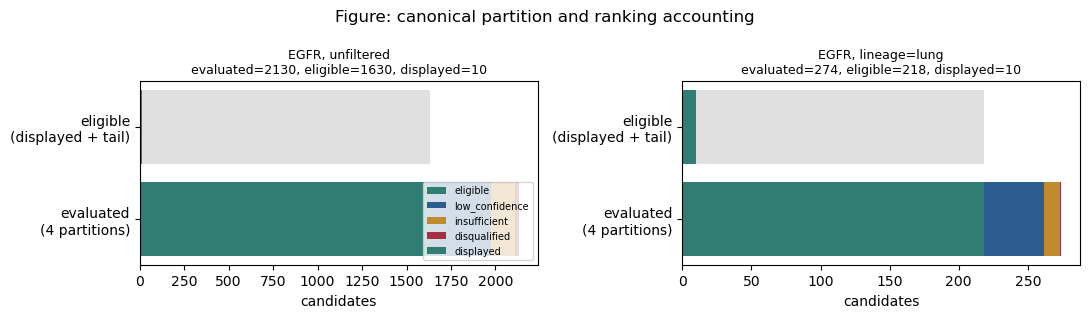

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

for ax, (query, label, _) in zip(axes, CANONICAL_CASES):
    r = native.loc[query]
    parts = [int(r.eligible), int(r.low_confidence), int(r.insufficient), int(r.disqualified)]
    part_labels = ["eligible", "low_confidence", "insufficient", "disqualified"]
    ax.barh(["evaluated\n(4 partitions)"], [r.evaluated], color="#c9c9c9")
    left = 0
    colors = ["#2f7d73", "#2c5d8f", "#c08a2e", "#a4303f"]
    for value, part_label, color in zip(parts, part_labels, colors):
        ax.barh(["evaluated\n(4 partitions)"], [value], left=left, label=part_label, color=color)
        left += value
    ax.barh(["eligible\n(displayed + tail)"], [r.eligible], color="#e0e0e0")
    ax.barh(["eligible\n(displayed + tail)"], [r.displayed], color="#2f7d73", label="displayed")
    ax.set_title(f"{label}\nevaluated={int(r.evaluated)}, eligible={int(r.eligible)}, displayed={int(r.displayed)}",
                 fontsize=9)
    ax.set_xlabel("candidates")
axes[0].legend(loc="lower right", fontsize=7, ncol=1)
fig.suptitle("Figure: canonical partition and ranking accounting")
fig.tight_layout()
plt.show()


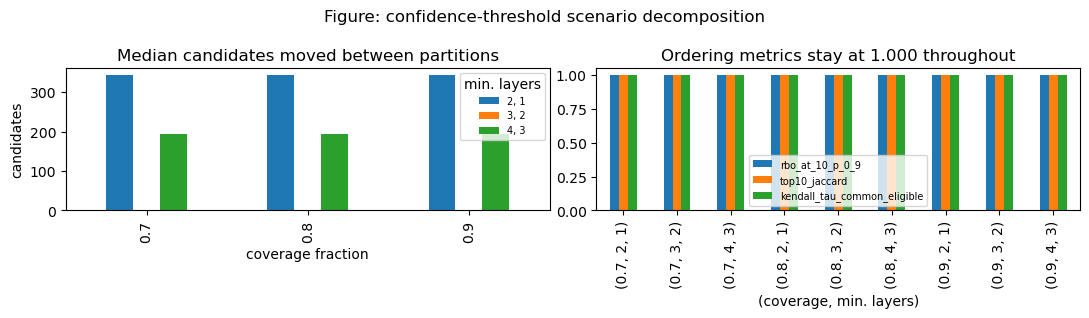

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

partition_grid.plot(kind="bar", ax=axes[0])
axes[0].set_title("Median candidates moved between partitions")
axes[0].set_xlabel("coverage fraction")
axes[0].set_ylabel("candidates")
axes[0].legend(title="min. layers", fontsize=7)

ordering_metrics_grid.plot(kind="bar", ax=axes[1])
axes[1].set_title("Ordering metrics stay at 1.000 throughout")
axes[1].set_xlabel("(coverage, min. layers)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=7)

fig.suptitle("Figure: confidence-threshold scenario decomposition")
fig.tight_layout()
plt.show()


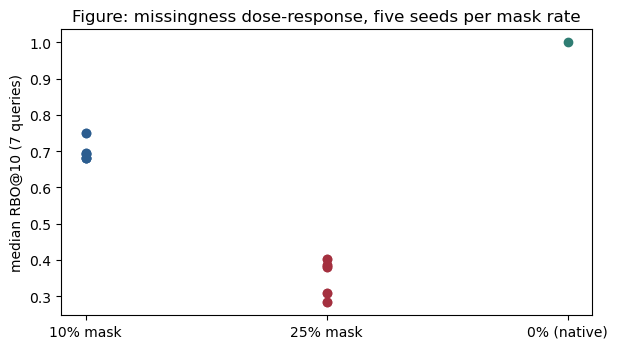

In [13]:
fig, ax = plt.subplots(figsize=(6.3, 3.6))

for rate_label, frame, color in [("10% mask", mask10, "#2c5d8f"), ("25% mask", mask25, "#a4303f")]:
    per_seed = frame.groupby("seed")[METRICS[0]].median()
    ax.scatter([rate_label] * len(per_seed), per_seed.values, color=color, alpha=0.8)
    ax.plot([rate_label] * len(per_seed), per_seed.values, "o", color=color)

native_rbo = float(passed[passed.variant == "full_native"][METRICS[0]].astype(float).median())
ax.scatter(["0% (native)"], [native_rbo], color="#2f7d73")

ax.set_ylabel("median RBO@10 (7 queries)")
ax.set_title("Figure: missingness dose-response, five seeds per mask rate")
fig.tight_layout()
plt.show()


## 11. External comparability of four published studies

**What:** Recomputes lineage-agreement, coverage, and correlation numbers against four external
published datasets.

**Why:** Checks whether this project's identity/lineage handling and scores agree with
independently collected data, as one form of external sanity check.

In [14]:
study_comparability = pd.read_csv(os.path.join(VALIDATION, "study_comparability.csv"))
print(study_comparability[["study", "mode", "comparable_to_ranking"]].to_string(index=False))


                            study                                            mode comparable_to_ranking
                Jin et al. (2023)                     marker_gene (LIHC/ALB only)               partial
TumorComparer (Sinha et al. 2021) gene_panel_qualitative (RTK-RAS/WNT, SKCM/LIHC)                    no
   Celligner (Warren et al. 2021)                                   coverage_only                    no
 NetCellMatch (Desai et al. 2022)                                   coverage_only                    no


In [15]:
celligner = pd.read_csv(os.path.join(VALIDATION, "celligner_coverage.csv"))
matched = celligner[celligner.matched_in_cell_lines_csv]
celligner_matched = len(matched)
celligner_lineage_agree = int(matched.lineage_agrees.sum())

print(f"Celligner: {celligner_matched} of {len(celligner)} rows resolve to a local ModelID; "
      f"{celligner_lineage_agree} of those {celligner_matched} agree on lineage")

assert (len(celligner), celligner_matched) == (1249, 1243)
assert celligner_lineage_agree == 1228
print("Celligner coverage numbers reproduce (1243/1249 matched, 1228/1243 lineage-agree)")


Celligner: 1243 of 1249 rows resolve to a local ModelID; 1228 of those 1243 agree on lineage
Celligner coverage numbers reproduce (1243/1249 matched, 1228/1243 lineage-agree)


In [16]:
netcellmatch = pd.read_csv(os.path.join(VALIDATION, "netcellmatch_coverage.csv"))
nc_matched = netcellmatch[netcellmatch.matched_in_cell_lines_csv]
nc_lineage_agree = int(nc_matched.lineage_agrees.sum())

print(f"NetCellMatch: {len(nc_matched)} of {len(netcellmatch)} breast-cohort rows resolve to a "
      f"local cell line; {nc_lineage_agree} of those {len(nc_matched)} agree on lineage")

assert (len(netcellmatch), len(nc_matched)) == (58, 52)
assert nc_lineage_agree == 52
print("NetCellMatch coverage numbers reproduce (52/58 matched, 52/52 lineage-agree)")


NetCellMatch: 52 of 58 breast-cohort rows resolve to a local cell line; 52 of those 52 agree on lineage
NetCellMatch coverage numbers reproduce (52/58 matched, 52/52 lineage-agree)


In [17]:
from scipy.stats import spearmanr

jin = pd.read_csv(os.path.join(VALIDATION, "jin2023_comparison.csv"))
marker_gene_scored = jin[(jin.query_mode == "marker_gene") & jin.our_D.notna()]

rho, pvalue = spearmanr(marker_gene_scored.jin_overall_rank, marker_gene_scored.our_rank_position)
print(f"Jin et al., marker-gene mode: n={len(marker_gene_scored)} scored lines, "
      f"cohort(s)={sorted(marker_gene_scored.tcga_cohort.unique())}, "
      f"Spearman rho={rho:.3f} between Jin's own overall rank and our rank position "
      "(both ascending, rank 1 = best)")

lineage_only_abandoned = (jin[jin.query_mode == "lineage_only"].status == "abandoned").all()
print("lineage_only mode abandoned for every one of the other cohorts "
      "(scorer raises on an empty gene filter):", bool(lineage_only_abandoned))

assert len(marker_gene_scored) == 24
assert abs(rho - 0.69) < 0.01
assert lineage_only_abandoned
print("\nJin et al. comparison reproduces (n=24, rho~=0.69), and the disclosed scorer "
      "defect that blocked the other 25 cohorts is still present")


Jin et al., marker-gene mode: n=24 scored lines, cohort(s)=['LIHC'], Spearman rho=0.686 between Jin's own overall rank and our rank position (both ascending, rank 1 = best)
lineage_only mode abandoned for every one of the other cohorts (scorer raises on an empty gene filter): True

Jin et al. comparison reproduces (n=24, rho~=0.69), and the disclosed scorer defect that blocked the other 25 cohorts is still present


In [18]:
tumorcomparer = pd.read_csv(os.path.join(VALIDATION, "tumorcomparer_comparison.csv"))

mean_d = tumorcomparer.groupby(["tcga_cohort", "pathway"]).our_D.mean().round(2)
print(mean_d.to_string())

# Sinha et al.'s own Fig. 4 claims RTK-RAS > WNT for SKCM, but WNT > RTK-RAS for LIHC --
# the two cohorts are claimed to go in *opposite* directions, which is what "directionally
# inconsistent" (as opposed to simply wrong) means below.
our_rtk_ras_higher = {
    "SKCM": bool(mean_d["SKCM", "RTK RAS"] > mean_d["SKCM", "WNT"]),
    "LIHC": bool(mean_d["LIHC", "RTK RAS"] > mean_d["LIHC", "WNT"]),
}
sinha_claims_rtk_ras_higher = {"SKCM": True, "LIHC": False}

skcm_agrees = our_rtk_ras_higher["SKCM"] == sinha_claims_rtk_ras_higher["SKCM"]
lihc_agrees = our_rtk_ras_higher["LIHC"] == sinha_claims_rtk_ras_higher["LIHC"]
print(f"\nSKCM: our data has RTK-RAS {'>' if our_rtk_ras_higher['SKCM'] else '<='} WNT -- "
      f"{'agrees with' if skcm_agrees else 'contradicts'} Sinha et al. Fig. 4")
print(f"LIHC: our data has RTK-RAS {'>' if our_rtk_ras_higher['LIHC'] else '<='} WNT -- "
      f"{'agrees with' if lihc_agrees else 'contradicts'} Sinha et al. Fig. 4")

assert skcm_agrees and not lihc_agrees, "expected agreement on SKCM and disagreement on LIHC"
print("\nTumorComparer comparison reproduces: directionally consistent on SKCM, "
      "inconsistent on LIHC -- reported as a genuine disagreement, not smoothed over")


tcga_cohort  pathway
LIHC         RTK RAS    0.25
             WNT        0.17
SKCM         RTK RAS    0.33
             WNT        0.29

SKCM: our data has RTK-RAS > WNT -- agrees with Sinha et al. Fig. 4
LIHC: our data has RTK-RAS > WNT -- contradicts Sinha et al. Fig. 4

TumorComparer comparison reproduces: directionally consistent on SKCM, inconsistent on LIHC -- reported as a genuine disagreement, not smoothed over


## 12. C5 alternatives policy, v1 vs v2

**What:** Reproduces a fixed seven-case comparison between the four-view and seven-view
alternatives policies.

**Why:** These numbers were hand-recorded from a separate evaluation run and are shown here as a
reference table, not recomputed from the stored records above.

In [19]:
alternatives_v1_v2 = pd.DataFrame([
    {"case": "egfr",                          "anchor": "ACH-000741", "v1_status": "ok",
     "v1_qual_cons": "33/36", "v2_status": "ok", "v2_qual_cons": "36/36"},
    {"case": "braf",                          "anchor": "ACH-000073", "v1_status": "no_qualifying_candidates",
     "v1_qual_cons": "0/88", "v2_status": "ok", "v2_qual_cons": "83/88"},
    {"case": "egfr_erbb2",                    "anchor": "ACH-002297", "v1_status": "no_qualifying_candidates",
     "v1_qual_cons": "0/72", "v2_status": "ok", "v2_qual_cons": "67/72"},
    {"case": "braf_map2k1",                   "anchor": "ACH-001972", "v1_status": "ok",
     "v1_qual_cons": "4/5", "v2_status": "ok", "v2_qual_cons": "4/5"},
    {"case": "kras_mapk1",                    "anchor": "ACH-001107", "v1_status": "no_qualifying_candidates",
     "v1_qual_cons": "0/54", "v2_status": "ok", "v2_qual_cons": "47/54"},
    {"case": "egfr_tp53_exclusion",           "anchor": "ACH-002083", "v1_status": "no_qualifying_candidates",
     "v1_qual_cons": "0/41", "v2_status": "ok", "v2_qual_cons": "39/41"},
    {"case": "egfr_most_populated_lineage",   "anchor": "ACH-001362", "v1_status": "no_qualifying_candidates",
     "v1_qual_cons": "0/217", "v2_status": "ok", "v2_qual_cons": "146/217"},
])
print(alternatives_v1_v2.to_string(index=False))

v1_zero_alternatives = int((alternatives_v1_v2.v1_status == "no_qualifying_candidates").sum())
v2_zero_alternatives = int((alternatives_v1_v2.v2_status == "no_qualifying_candidates").sum())
print(f"\nv1 returned zero alternatives in {v1_zero_alternatives} of 7 real cases; "
      f"v2 returned zero in {v2_zero_alternatives} of 7")

assert v1_zero_alternatives == 5
assert v2_zero_alternatives == 0
print("\nreproduces the stated coverage difference: v1 fails on 5/7 real anchors "
      "that v2 (with three additional views) covers; this describes software coverage under "
      "each policy's own eligibility rule, not a biological claim about any of the returned "
      "alternatives")


                       case     anchor                v1_status v1_qual_cons v2_status v2_qual_cons
                       egfr ACH-000741                       ok        33/36        ok        36/36
                       braf ACH-000073 no_qualifying_candidates         0/88        ok        83/88
                 egfr_erbb2 ACH-002297 no_qualifying_candidates         0/72        ok        67/72
                braf_map2k1 ACH-001972                       ok          4/5        ok          4/5
                 kras_mapk1 ACH-001107 no_qualifying_candidates         0/54        ok        47/54
        egfr_tp53_exclusion ACH-002083 no_qualifying_candidates         0/41        ok        39/41
egfr_most_populated_lineage ACH-001362 no_qualifying_candidates        0/217        ok      146/217

v1 returned zero alternatives in 5 of 7 real cases; v2 returned zero in 0 of 7

reproduces the stated coverage difference: v1 fails on 5/7 real anchors that v2 (with three additional views) covers; t

## 13. Closing note

**What:** Summarises what the checks above do and do not show.

**Why:** A reproducible computation is not the same as a validated one, and that distinction
matters for how these results should be read.